# Weather Data Analysis — Linear Regression

This notebook explores a weather dataset, cleans it, engineers features, and trains regression models (Linear, Ridge, Lasso) to predict temperature from other weather measurements. Each section below is labeled with a heading and the code includes short comments explaining what each line does.

## 1. Import Libraries

Import pandas, plotting libraries, numpy, and the scikit-learn tools used for modeling.

In [1]:
import pandas as pd # for loading and manipulating tabular data
import matplotlib.pyplot as plt # for plotting charts
import seaborn as sns # for nicer statistical plots (heatmap, boxplot)
import numpy as np # for numerical operations
from sklearn.model_selection import train_test_split # to split data into train/test sets
from sklearn.linear_model import LinearRegression, Ridge, Lasso # regression models to compare
from sklearn.preprocessing import PolynomialFeatures,StandardScaler,RobustScaler # tools for feature scaling
from sklearn.metrics import mean_squared_error, r2_score # metrics to evaluate model performance

## 2. Load the Dataset

Read the weather CSV file into a DataFrame and take a first look at its structure.

In [3]:
df = pd.read_csv('/Users/theabood/Desktop/weather_data_extended.csv') # load the raw CSV data
df.info() # show column names, types, and non-null counts
df.head() # preview the first 5 rows

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Location           800 non-null    object 
 1   Observation Time   800 non-null    object 
 2   Temperature (°C)   800 non-null    float64
 3   Feels Like (°C)    800 non-null    float64
 4   Humidity (%)       800 non-null    int64  
 5   Wind Speed (kph)   800 non-null    float64
 6   Weather Condition  800 non-null    object 
 7   Cloud Cover (%)    800 non-null    int64  
 8   Pressure (mb)      800 non-null    int64  
 9   UV Index           800 non-null    int64  
 10  Visibility (km)    800 non-null    int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 68.9+ KB


,Location,Observation Time,Temperature (°C),Feels Like (°C),Humidity (%),Wind Speed (kph),Weather Condition,Cloud Cover (%),Pressure (mb),UV Index,Visibility (km)
0,New York,4/5/2024 14:15,8.3,4.5,40,29.9,Partly cloudy,75,1003,2,16
1,New York,4/5/2024 14:15,8.3,4.5,40,29.9,Partly cloudy,75,1003,2,16
2,New York,4/5/2024 14:15,8.3,4.5,40,29.9,Partly cloudy,75,1003,2,16
3,New York,4/5/2024 14:15,8.3,4.5,40,29.9,Partly cloudy,75,1003,2,16
4,New York,4/5/2024 14:15,8.3,4.5,40,29.9,Partly cloudy,75,1003,2,16


## 3. Check for Missing Values

Count how many missing (null) values exist in each column.

In [4]:
df.isnull().sum() # count missing values per column

Location             0
Observation Time     0
Temperature (°C)     0
Feels Like (°C)      0
Humidity (%)         0
Wind Speed (kph)     0
Weather Condition    0
Cloud Cover (%)      0
Pressure (mb)        0
UV Index             0
Visibility (km)      0
dtype: int64

## 4. Remove Missing Values

Drop any rows that contain missing data so the model only trains on complete records.

In [5]:
#dropping missing values
df=df.dropna() # remove rows with any missing values

## 5. Statistical Summary

Generate summary statistics (mean, std, min, max, quartiles) for the numeric columns.

In [6]:
df.describe() # summary stats for numeric columns

,Temperature (°C),Feels Like (°C),Humidity (%),Wind Speed (kph),Cloud Cover (%),Pressure (mb),UV Index,Visibility (km)
count,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,16.53750,16.312500,73.375000,16.200000,43.750000,1013.125000,1.750000,10.750000
std,5.58223,7.397601,16.547709,10.343052,34.820297,6.493233,1.090406,1.985555
min,8.30000,4.500000,40.000000,3.600000,0.000000,1003.000000,1.000000,10.000000
25%,13.75000,12.375000,66.500000,6.625000,0.000000,1010.500000,1.000000,10.000000
50%,15.50000,15.900000,74.000000,14.600000,62.500000,1012.500000,1.000000,10.000000
75%,20.25000,20.625000,81.250000,25.550000,75.000000,1015.750000,2.250000,10.000000
max,25.00000,27.800000,100.000000,29.900000,75.000000,1024.000000,4.000000,16.000000


## 6. Encode the 'Location' Column

Convert the text-based Location column into numeric codes so it can be used as a model feature, then show which code maps to which city.

In [7]:
# String indexing on 'Location' column: Converting Location column from string to integer
df['Location_index'] = df['Location'].astype('category').cat.codes # turn city names into numeric codes

# Get unique values from each column
unique_locations = df['Location'].drop_duplicates().reset_index(drop=True) # list of unique city names
unique_location_indices = df['Location_index'].drop_duplicates().reset_index(drop=True) # matching numeric codes

# Create a new DataFrame with both columns
unique_df = pd.DataFrame({ # combine names and codes into one table
    'Unique_Locations': unique_locations,
    'Unique_Location_Indices': unique_location_indices
})
unique_df # display the name-to-code mapping

,Unique_Locations,Unique_Location_Indices
0,New York,3
1,London,2
2,Tokyo,7
3,Paris,4
4,Sydney,6
5,Dubai,0
6,Rome,5
7,Hong Kong,1


## 7. Correlation Heatmap

Visualize how strongly each numeric feature correlates with the others.

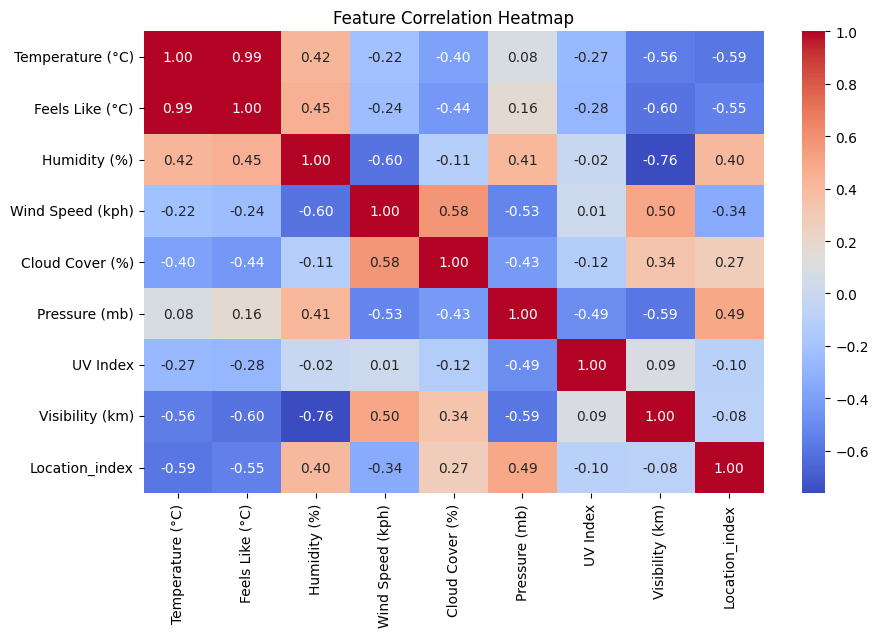

In [8]:
# Select only numeric columns before correlation
numeric_df = df.select_dtypes(include=['number']) # keep only numeric columns for correlation

# Correlation heatmap
plt.figure(figsize=(10, 6)) # set the plot size
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f') # draw the correlation heatmap with values
plt.title('Feature Correlation Heatmap') # add a title
plt.show() # display the plot

## 8. Check for Outliers

Use a boxplot to visually inspect the spread and outliers in the Pressure column.

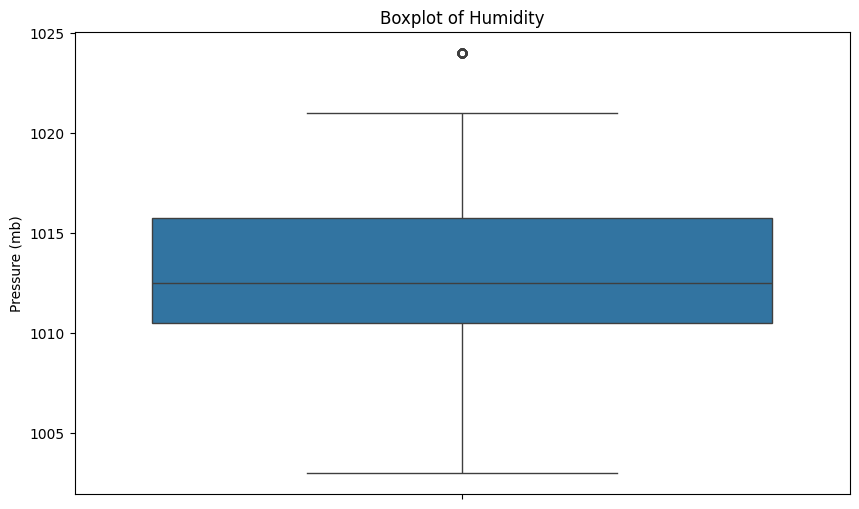

In [9]:
plt.figure(figsize=(10, 6)) # set the plot size
sns.boxplot(data=df['Pressure (mb)']) # boxplot to spot outliers in pressure values
plt.title('Boxplot of Humidity') # add a title
plt.show() # display the plot

## 9. Define Features (X) and Target (y)

Select the input features used to predict temperature, and set Temperature as the target variable.

In [10]:
X = df[['Humidity (%)', 'Wind Speed (kph)', 'Pressure (mb)', 'Visibility (km)', 'Location_index']] # input features for the model
y = df['Temperature (°C)'] # value we want to predict

## 10. Scale the Features

Scale the features with RobustScaler (less sensitive to outliers) so they're on comparable ranges.

In [11]:
# Standard scaling the values in features
scaler = RobustScaler() # scaler that is robust to outliers
df_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns) # fit and transform the features
print(df_scaled.describe()) # check the scaled feature statistics

       Humidity (%)  Wind Speed (kph)  Pressure (mb)  Visibility (km)  \
count    800.000000        800.000000     800.000000       800.000000   
mean      -0.042373          0.084544       0.119048         0.750000   
std        1.121879          0.546529       1.236806         1.985555   
min       -2.305085         -0.581242      -1.809524         0.000000   
25%       -0.508475         -0.421400      -0.380952         0.000000   
50%        0.000000          0.000000       0.000000         0.000000   
75%        0.491525          0.578600       0.619048         0.000000   
max        1.762712          0.808454       2.190476         6.000000   

       Location_index  
count    8.000000e+02  
mean    -1.776357e-17  
std      6.550632e-01  
min     -1.000000e+00  
25%     -5.000000e-01  
50%      0.000000e+00  
75%      5.000000e-01  
max      1.000000e+00  


## 11. Split Data into Train and Test Sets

Reserve 20% of the data for testing so the model's performance can be checked on unseen data.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 80/20 train-test split

## 12. Train a Linear Regression Model

Create a simple Linear Regression model and fit it on the training data.

In [13]:
model = LinearRegression() # create the model
model.fit(X_train, y_train) # train it on the training data

LinearRegression()

## 13. Make Predictions

Use the trained model to predict temperature values for the test set.

In [14]:
y_pred = model.predict(X_test) # predict temperature on unseen test data

## 14. Evaluate the Model

Measure how well the model performed using Mean Squared Error (lower is better) and R² Score (closer to 1 is better).

In [15]:
mse = mean_squared_error(y_test, y_pred) # average squared prediction error
r2 = r2_score(y_test, y_pred) # proportion of variance explained by the model
print(f'Mean Squared Error: {mse:.2f}') # print the MSE
print(f'R-squared Score: {r2:.2f}') # print the R² score

Mean Squared Error: 1.33
R-squared Score: 0.96


## 15. Visualize Actual vs. Predicted Values

Plot actual temperatures against predicted temperatures to see how closely they align.

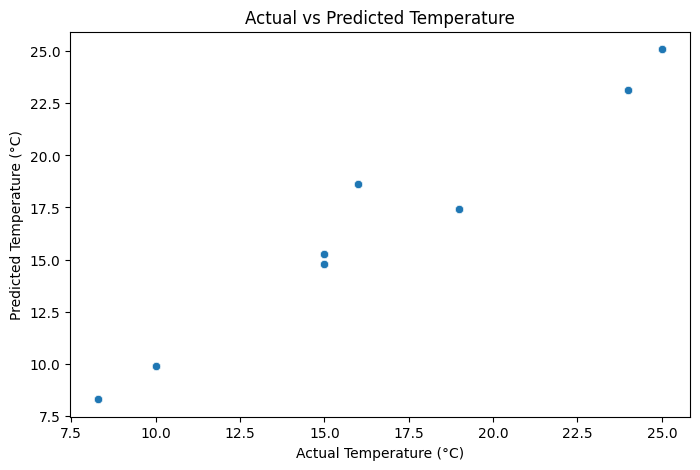

In [16]:
plt.figure(figsize=(8, 5)) # set the plot size
sns.scatterplot(x=y_test, y=y_pred) # scatter of actual vs predicted values
plt.xlabel('Actual Temperature (°C)') # label the x-axis
plt.ylabel('Predicted Temperature (°C)') # label the y-axis
plt.title('Actual vs Predicted Temperature') # add a title
plt.show() # display the plot

## 16. Compare Multiple Regression Models

Train Linear, Ridge, and Lasso regression models and compare their MSE and R² scores side by side.

In [17]:
# Define models
models = { # dictionary of models to compare
    "Simple Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
}

# Store results
results = {} # store each model's evaluation results

# Train and evaluate each model
for name, model in models.items(): # loop through each model
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {"MSE": mse, "R² Score": r2}

# Convert results to DataFrame and display
results_df = pd.DataFrame(results).T # convert results into a table
print(results_df) # display the comparison table

                               MSE  R² Score
Simple Linear Regression  1.327603  0.961545
Ridge Regression          1.327779  0.961540
Lasso Regression          1.369720  0.960325


## 17. Visualize Model Comparison

Plot a bar chart comparing the MSE and R² score of each regression model.

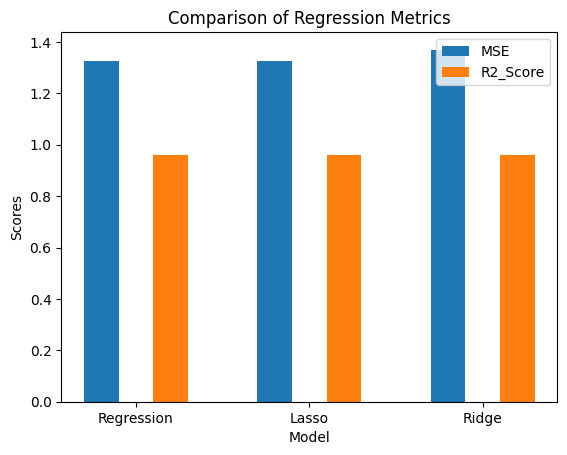

In [18]:
# plot comparison
import matplotlib.pyplot as plt # plotting library
import numpy as np # numerical operations

mse = results_df['MSE'] # MSE values for each model
r2_score = results_df['R² Score'] # R² values for each model

positions = np.arange(len(mse)) # x-axis positions for bars
bar_width = 0.2 # width of each bar

plt.bar(positions - bar_width, mse, width = bar_width, label = 'MSE') # bars for MSE
plt.bar(positions + bar_width, r2_score, width = bar_width, label = 'R2_Score') # bars for R² score

# adding labels and title
plt.xlabel('Model') # label the x-axis
plt.ylabel('Scores') # label the y-axis
plt.title('Comparison of Regression Metrics') # add a title

# adding the legend
plt.legend() # show the legend
plt.xticks(positions, ['Regression', 'Lasso', 'Ridge']) # label each group of bars
plt.show() # display the chart